# BAB X: Pra-pemrosesan Data (Data Preprocessing)

Tahapan pra-pemrosesan data bertujuan untuk mengubah data mentah (riwayat obrolan WhatsApp) menjadi format yang terstruktur, bersih, dan siap untuk diekstraksi fiturnya. Karena data teks dari media sosial umumnya mengandung banyak derau (*noise*), tahapan ini dilakukan secara sekuensial dan sistematis.

## 1. Pembacaan dan Inspeksi Data Mentah (*Data Ingestion & Initial Profiling*)

**Tujuan Akademis:** Mengenali struktur kolom, tipe data, serta mengeksplorasi anomali atau tipe pesan non-teks yang secara bawaan (*default*) dihasilkan oleh sistem ekspor WhatsApp.
**Tindakan:** Memuat *file* `master_chat_wa.csv` ke dalam *DataFrame*, melihat ringkasan informasi, dan menampilkan frekuensi isi pesan (`Message Body`) untuk mendeteksi *noise*.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Membaca data mentah
df_raw = pd.read_csv('master_chat_wa.csv')

# 2. Inspeksi struktur data
print("--- Informasi Struktur Dataset Mentah ---")
df_raw.info()

# 3. Inspeksi sampel data dan deteksi anomali/noise pada teks
print("\n--- Top 15 Isi Pesan Terbanyak (Deteksi Noise) ---")
print(df_raw['Message Body'].value_counts().head(15))

--- Informasi Struktur Dataset Mentah ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3502 entries, 0 to 3501
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country         3502 non-null   object
 1   Phone Number    3502 non-null   int64 
 2   Formatted Name  3502 non-null   object
 3   Display Name    3418 non-null   object
 4   Message Time    3502 non-null   object
 5   Message Type    3502 non-null   object
 6   Message Body    3447 non-null   object
 7   Message Id      3502 non-null   object
dtypes: int64(1), object(7)
memory usage: 219.0+ KB

--- Top 15 Isi Pesan Terbanyak (Deteksi Noise) ---
Message Body
【IMAGE】              331
Anugerah komputer     59
Oke kak               45
Ok                    41
Oke bang              36
Iya kak               24
Ok bg                 17
Anugerah Computer     16
Ok kk                 15
Okee kak              15
Oke bg                14
【VIDEO】             

## 2. Penyaringan Teks dan Pembuangan Derau (*Data Filtering & Noise Removal*)

**Tujuan Akademis:** Memisahkan data teks murni yang relevan untuk analisis dari data yang tidak berguna bagi model.
**Tindakan Berdasarkan Hasil Inspeksi:**
1. Berdasarkan struktur kolom `Message Id`, kita mengidentifikasi bahwa pesan masuk dari pelanggan diawali dengan `false_`, sedangkan pesan keluar dari admin diawali dengan `true_`. Maka, kita filter khusus awalan `false_`.
2. Berdasarkan inspeksi isi pesan, ditemukan adanya data multimedia atau sistem (seperti `【IMAGE】`, `【VIDEO】`, atau `【DOCUMENT】`). Karena model NLP kita hanya memproses teks, semua baris yang mengandung pola kurung siku tebal `【...】` akan dihapus menggunakan *Regular Expression* (RegEx).
3. Menghapus baris kosong (NaN) dan menghapus duplikasi kalimat agar tidak terjadi bias repetisi.

In [3]:
import re

# Tindakan 1: Filter HANYA pesan pelanggan (inbound)
df_customer = df_raw[df_raw['Message Id'].astype(str).str.startswith('false_')].copy()

# Tindakan 2: Hapus pesan non-teks (gambar, video, dokumen, dll yang menggunakan format 【...】)
noise_pattern = r'【.*?】'
df_customer = df_customer[~df_customer['Message Body'].astype(str).str.contains(noise_pattern, regex=True)]

# Menghapus pesan yang kosong (NaN/Null)
df_unique = df_customer.dropna(subset=['Message Body'])

# Tindakan 3: Hapus duplikasi untuk validasi yang lebih efisien
# df_unique = df_customer.drop_duplicates(subset=['Message Body']).copy()

print(f"Hasil Penyaringan: Ditemukan {len(df_unique)} baris pesan teks unik dari pelanggan siap diproses.")

Hasil Penyaringan: Ditemukan 1581 baris pesan teks unik dari pelanggan siap diproses.


## 3. Pembersihan Teks Dasar (*Basic Text Cleaning*)

**Tujuan Akademis:** Menyeragamkan format huruf dan menghilangkan karakter asing yang tidak memberikan nilai semantik.
**Tindakan:** Mengubah seluruh teks menjadi huruf kecil (*case folding*), serta menghapus tautan internet (URL), angka, dan tanda baca sehingga hanya menyisakan karakter alfabet dan spasi tunggal.

In [4]:
def clean_text(text):
    text = str(text).lower() # Case folding
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus URL
    text = re.sub(r'[^a-z\s]', '', text) # Hapus karakter non-alfabet (angka, simbol, tanda baca)
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi ganda
    return text

# Menerapkan fungsi cleaning
df_unique['Cleaned_Message'] = df_unique['Message Body'].apply(clean_text)

# Membuang baris yang teksnya habis/menjadi kosong setelah karakter asingnya dihapus
df_unique = df_unique[df_unique['Cleaned_Message'] != '']

print("Hasil: Pratinjau Teks Asli vs Teks Bersih")
display(df_unique[['Message Body', 'Cleaned_Message']].head())

Hasil: Pratinjau Teks Asli vs Teks Bersih


,Message Body,Cleaned_Message
2,Oke bg,oke bg
3,Bg berapa kemarin harganya ya,bg berapa kemarin harganya ya
5,Okey bg,okey bg
7,Tutup jam brp bg,tutup jam brp bg
9,Okey bg bntr lagi saya kesana,okey bg bntr lagi saya kesana


## 4. Pelabelan Heuristik Awal (*Initial Rule-Based Labeling*)

**Tujuan Akademis:** Membuat hipotesis label kelas awal sebelum diverifikasi oleh pakar manusia. Ini mempermudah dan mempercepat proses pembuatan *Ground Truth*.
**Tindakan:** Memberikan label secara heuristik menggunakan kamus kata kunci lokal (*keyword dictionary*) untuk kelas `setuju` dan `batal`. Kalimat yang tidak memuat kata kunci tersebut akan otomatis masuk ke kelas `lainnya`.

In [5]:
def initial_label(text):
    keywords_setuju = ['lanjut', 'setuju', 'sikat', 'oke', 'boleh', 'iyak', 'ganti', 'kerjakan', 'aman', 'gas']
    keywords_batal = ['batal', 'cancel', 'ndak usah', 'kemahalan', 'mahal', 'ndak jadi', 'nanti dolok', 'ambe balek']
    
    if any(word in text for word in keywords_batal):
        return 'batal'
    elif any(word in text for word in keywords_setuju):
        return 'setuju'
    else:
        return 'lainnya'

# Menerapkan pelabelan awal
df_unique['Intent_Awal'] = df_unique['Cleaned_Message'].apply(initial_label)

display(df_unique[['Cleaned_Message', 'Intent_Awal']].tail())

,Cleaned_Message,Intent_Awal
3490,waalaikumsalam balik dari kuliah bisa kah saya...,lainnya
3494,klo isi pes msh smpat ga bg,lainnya
3496,ok,lainnya
3497,btr lg sy turun,lainnya
3500,baik bg nnti saya ambil,lainnya


## 5. Ekspor Data untuk Validasi Manual (*Ground Truth Validation*)

**Tujuan Akademis:** Menghindari label palsu/salah (*False Labeling*) yang dihasilkan dari skrip otomatis. Validasi manual oleh peneliti (*Human-in-the-loop*) bertindak sebagai kontrol kualitas akhir sebelum data dilanjutkan ke tahap analisis ketidakseimbangan kelas (*Imbalanced Data Analysis*) dan pemodelan.
**Tindakan:** Menyimpan *dataset* yang telah dilabeli awal ke dalam format CSV agar dapat dikoreksi di luar sistem (*spreadsheet*).

In [7]:
# Mempersiapkan format ekspor
df_export = df_unique[['Message Time', 'Display Name', 'Message Body', 'Cleaned_Message', 'Intent_Awal']].copy()
df_export.rename(columns={'Message Body': 'Teks_Asli', 'Intent_Awal': 'Label_Validasi'}, inplace=True)

# Simpan ke CSV
file_validasi = 'data_mentah_untuk_validasi.csv'
df_export.to_csv(file_validasi, index=False)

print(f"✅ HASIL: Data diekspor ke '{file_validasi}'.")
print("--> TINDAKAN BERIKUTNYA: Lakukan validasi manual pada file tersebut, perbaiki kolom 'Label_Validasi', lalu simpan.")

✅ HASIL: Data diekspor ke 'data_mentah_untuk_validasi.csv'.
--> TINDAKAN BERIKUTNYA: Lakukan validasi manual pada file tersebut, perbaiki kolom 'Label_Validasi', lalu simpan.


## 6. Analisis Data Eksploratif Pasca-Validasi (*Post-Validation EDA*)

**Tujuan Akademis:** Mendiagnosis kondisi distribusi kelas (*Class Distribution*) setelah label dipastikan 100% benar (telah divalidasi manual oleh peneliti sebagai *Ground Truth*).
**Tindakan:** Membaca kembali *file* `data_mentah_untuk_validasi.csv` yang telah direvisi, kemudian memvisualisasikan jumlah data per kelas niat (*intent*).
**Hasil:** Teridentifikasi adanya fenomena Ketidakseimbangan Kelas Ekstrem (*Severe Class Imbalance*), di mana kelas `lainnya` sangat mendominasi dibandingkan kelas `setuju` dan `batal`. Kondisi ini mengharuskan adanya tindakan penyeimbangan data agar model tidak bias.

Variasi label yang terdeteksi di Excel Anda:
['setuju' 'lainnya' 'batal']
------------------------------
--- Hasil: Distribusi Kelas Aktual (Ground Truth) ---
intent
lainnya    1145
setuju      389
batal        34
Name: count, dtype: int64


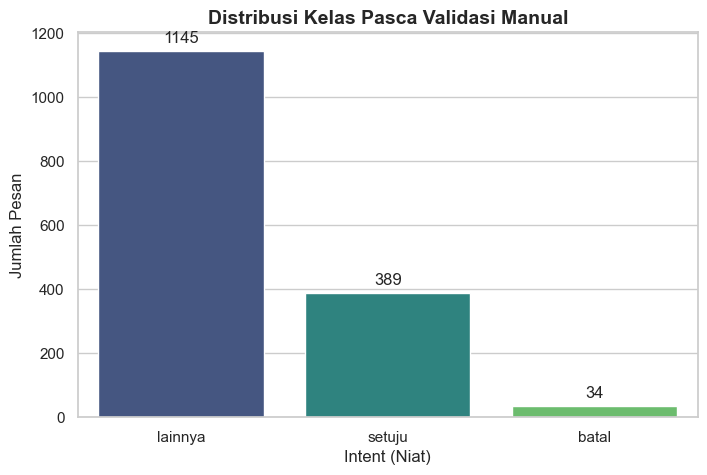

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Membaca data yang SUDAH divalidasi manual
df_validated = pd.read_csv('data_mentah_untuk_validasi.csv')

# Rename agar standar untuk proses selanjutnya
df_validated.rename(columns={'Label_Validasi': 'intent'}, inplace=True)

# Ubah semua teks di kolom intent menjadi string, huruf kecil (lower), dan hapus spasi kiri-kanan (strip)
df_validated['intent'] = df_validated['intent'].astype(str).str.lower().str.strip()

# Mari kita cek apakah ada ketikan yang aneh (selain setuju, batal, lainnya)
print("Variasi label yang terdeteksi di Excel Anda:")
print(df_validated['intent'].unique())
print("-" * 30)
# ==========================================

print("--- Hasil: Distribusi Kelas Aktual (Ground Truth) ---")
dist = df_validated['intent'].value_counts()
print(dist)

# Visualisasi
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=dist.index, y=dist.values, palette='viridis')
plt.title('Distribusi Kelas Pasca Validasi Manual', fontsize=14, fontweight='bold')
plt.xlabel('Intent (Niat)', fontsize=12)
plt.ylabel('Jumlah Pesan', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

## 7. Strategi Penyeimbangan Data (*Hybrid Data Balancing & Augmentation*)

**Tujuan Akademis:** Mencegah bias pada model klasifikasi. Mengacu pada hasil *Ground Truth* (Lainnya: 970, Setuju: 296, Batal: 9), jika data diteruskan dalam kondisi timpang, model akan mengabaikan kelas minoritas dan cenderung selalu menebak kelas mayoritas (`lainnya`).
**Tindakan:** Menerapkan strategi *Hybrid Sampling* dengan target ekuilibrium (keseimbangan) sebanyak **500 sampel per kelas**:
1. **Undersampling**: Memangkas jumlah data kelas `lainnya` secara acak dari 970 menjadi 500 sampel.
2. **Generative Oversampling (LLM)**: Menggunakan Groq API (model Llama-3) untuk menyintesis percakapan gaya lokal Pontianak guna menambah sampel kelas `setuju` (butuh ~204 tambahan) dan `batal` (butuh ~480 tambahan) hingga mencapai target 500.
3. **Extreme Typo Injection**: Memasukkan daftar kesalahan eja (*typo*) ekstrem yang sering muncul di obrolan pelanggan, dan memberikannya bobot ganda agar model tahan (*robust*) terhadap teks yang rusak.
**Hasil:** *Dataset* final yang seimbang, bervariasi, dan siap diekstraksi menggunakan algoritma *Machine Learning*.

In [2]:
import os
import time
import re
import pandas as pd
from groq import Groq
from dotenv import load_dotenv

TARGET_SAMPLES = 500

# 1. UNDERSAMPLING KELAS MAYORITAS
df_lainnya = df_validated[df_validated['intent'] == 'lainnya']
if len(df_lainnya) > TARGET_SAMPLES:
    df_lainnya = df_lainnya.sample(n=TARGET_SAMPLES, random_state=42)

df_setuju = df_validated[df_validated['intent'] == 'setuju']
df_batal = df_validated[df_validated['intent'] == 'batal']

df_hybrid = pd.concat([df_lainnya, df_setuju, df_batal], ignore_index=True)
df_hybrid['source'] = 'real'

if 'Teks_Asli' in df_hybrid.columns:
    df_hybrid.rename(columns={'Teks_Asli': 'text', 'Cleaned_Message': 'clean_text'}, inplace=True)
elif 'Message Body' in df_hybrid.columns:
    df_hybrid.rename(columns={'Message Body': 'text', 'Cleaned_Message': 'clean_text'}, inplace=True)

print(f"✅ Undersampling selesai. Kelas 'lainnya' menjadi {len(df_lainnya)} sampel.")

# 2. GENERATIVE OVERSAMPLING MENGGUNAKAN GROQ
load_dotenv('.env') 
groq_api_key = os.getenv("GROQ_API_KEY")

if not groq_api_key:
    load_dotenv('../anugerah-computer/.env')
    groq_api_key = os.getenv("GROQ_API_KEY")

client = Groq(api_key=groq_api_key)

def generate_synthetic_data(intent, num_samples):
    prompt = f"""Buat {num_samples} kalimat obrolan WhatsApp pelanggan ke tempat servis komputer untuk kategori: '{intent}'.\n
Gunakan bahasa gaul Pontianak/Indonesia sehari-hari.\n
Format keluaran: Cukup daftarkan kalimatnya satu per baris tanpa nomor urut, tanda hubung, atau tanda bintang.\n"""
    try:
        completion = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.8, max_tokens=1500,
        )
        result = completion.choices[0].message.content.strip()
        lines = [re.sub(r'^\d+\.\s*|^-\s*|\*+', '', line).strip() for line in result.split('\n') if len(line.strip()) > 3]
        return lines[:num_samples]
    except Exception as e:
        print(f"Error LLM: {e}")
        return []

synthetic_texts = []
synthetic_labels = []

print("\nMemulai Generative Oversampling dengan Groq AI...")
for intent in ['setuju', 'batal']:
    current_count = len(df_validated[df_validated['intent'] == intent])
    if current_count < TARGET_SAMPLES:
        needed = TARGET_SAMPLES - current_count
        print(f" - Meng-generate {needed} data untuk kelas '{intent}'...")
        
        while needed > 0:
            batch_size = min(needed, 40)
            new_sentences = generate_synthetic_data(intent, batch_size)
            if new_sentences:
                synthetic_texts.extend(new_sentences)
                synthetic_labels.extend([intent] * len(new_sentences))
                needed -= len(new_sentences)
            time.sleep(1.5)

df_synth = pd.DataFrame({'text': synthetic_texts, 'intent': synthetic_labels, 'source': 'synthetic'})
df_synth['clean_text'] = df_synth['text'].apply(clean_text)

print(f"✅ Oversampling selesai. Berhasil membuat {len(df_synth)} data sintetis.")

NameError: name 'df_validated' is not defined

In [10]:
# 3. EXTREME TYPO INJECTION
print("Menyuntikkan Typo Ekstrem (Extreme Typo Injection)...")
setuju_typos = ['stju', 'stuju', 'setju', 'ok', 'oke', 'ok bg', 'lanjut', 'lnjt', 'gass', 'y', 'y bg', 'gas']
batal_typos = ['btl', 'batalin', 'ga jadi', 'gajadi', 'gk jd', 'gk jdi', 'cancel', 'cncl', 'kemahalan', 'mahal', 'g usah']

typo_data = [{"text": t, "clean_text": clean_text(t), "intent": "setuju", "source": "synthetic_typo"} for t in setuju_typos] + \
            [{"text": t, "clean_text": clean_text(t), "intent": "batal", "source": "synthetic_typo"} for t in batal_typos]

# Gandakan typo (dikali 3)
df_typo = pd.DataFrame(typo_data * 3)

# 4. GABUNGKAN SEMUA & FILTER KOLOM
df_final = pd.concat([df_hybrid, df_synth, df_typo], ignore_index=True)
df_final = df_final.dropna(subset=['clean_text', 'intent'])
df_final = df_final[df_final['clean_text'] != '']

df_final = df_final[['text', 'intent', 'source', 'clean_text']]

# EXPORT
file_final = 'dataset_labeled.csv'
df_final.to_csv(file_final, index=False)

print(f"✅ PROSES SELESAI! Data final berhasil diekspor ke '{file_final}'")
print("\n--- Distribusi Akhir ---")
print(df_final['intent'].value_counts())

Menyuntikkan Typo Ekstrem (Extreme Typo Injection)...
✅ PROSES SELESAI! Data final berhasil diekspor ke 'dataset_labeled.csv'

--- Distribusi Akhir ---
intent
setuju     536
batal      533
lainnya    500
Name: count, dtype: int64


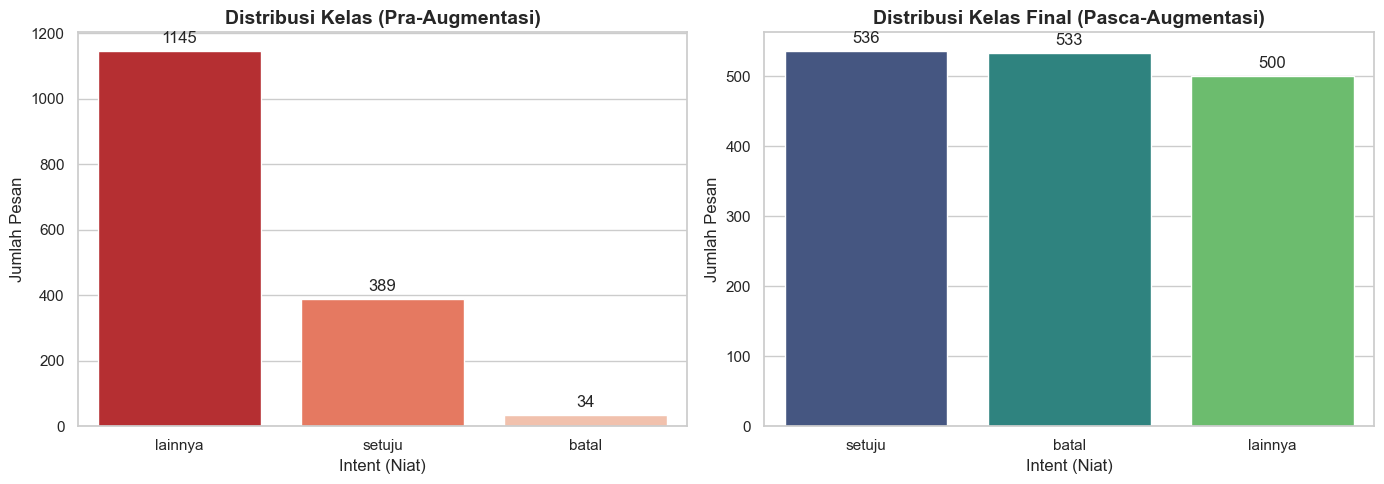

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik Kiri: Data Sebelum Augmentasi
dist_asli = df_validated['intent'].value_counts()
ax1 = sns.barplot(x=dist_asli.index, y=dist_asli.values, palette='Reds_r', ax=axes[0])
axes[0].set_title('Distribusi Kelas (Pra-Augmentasi)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Intent (Niat)', fontsize=12)
axes[0].set_ylabel('Jumlah Pesan', fontsize=12)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# Grafik Kanan: Data Sesudah Augmentasi (Siap Latih)
dist_bal = df_final['intent'].value_counts()
ax2 = sns.barplot(x=dist_bal.index, y=dist_bal.values, palette='viridis', ax=axes[1])
axes[1].set_title('Distribusi Kelas Final (Pasca-Augmentasi)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Intent (Niat)', fontsize=12)
axes[1].set_ylabel('Jumlah Pesan', fontsize=12)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()